####  STEP 1: Import the Required Libraries

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

TensorFlow Version: 2.21.0
NumPy Version: 2.4.6


#### STEP 2: Define the Project Directory

In [2]:
PROJECT_DIR = Path.cwd().parent

TRAIN_DIR = PROJECT_DIR / "dataset" / "Train"
VALIDATION_DIR = PROJECT_DIR / "dataset" / "Validation"
TEST_DIR = PROJECT_DIR / "dataset" / "Test"

print("Project Directory:", PROJECT_DIR)
print("Training Directory:", TRAIN_DIR)
print("Validation Directory:", VALIDATION_DIR)
print("Testing Directory:", TEST_DIR)

Project Directory: c:\Users\Monerics\Desktop\Tomato-Disease-Classifier
Training Directory: c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\Train
Validation Directory: c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\Validation
Testing Directory: c:\Users\Monerics\Desktop\Tomato-Disease-Classifier\dataset\Test


####  STEP 3: Verify Dataset Directories

In [3]:
print("Training Exists:", TRAIN_DIR.exists())
print("Validation Exists:", VALIDATION_DIR.exists())
print("Testing Exists:", TEST_DIR.exists())

Training Exists: True
Validation Exists: True
Testing Exists: True


#### STEP 4: Display the Folder Structure

In [4]:

# STEP 4: Display the Dataset Classes

print("Training Classes")

for folder in TRAIN_DIR.iterdir():
    if folder.is_dir():
        print("-", folder.name)

Training Classes
- Tomato_Early_blight
- Tomato_healthy


#### STEP 5: Count Images in Each Class

In [5]:

# STEP 5: Count Images in Each Class


for folder in TRAIN_DIR.iterdir():

    if folder.is_dir():

        total_images = len(list(folder.glob("*")))

        print(f"{folder.name}: {total_images} images")

Tomato_Early_blight: 800 images
Tomato_healthy: 1272 images


#### STEP 6: Define Image Parameters

In [6]:

# STEP 6: Define Image Parameters


IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42

#### STEP 7: Load the Datasets

In [7]:

# STEP 7: Load the Training, Validation and Testing Datasets


train_dataset = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

validation_dataset = tf.keras.utils.image_dataset_from_directory(

    VALIDATION_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED

)

test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False

)

Found 2072 files belonging to 2 classes.
Found 260 files belonging to 2 classes.
Found 259 files belonging to 2 classes.


#### STEP 8: Display the Class Names

In [8]:

# STEP 8: Display Class Labels


class_names = train_dataset.class_names

print(class_names)

['Tomato_Early_blight', 'Tomato_healthy']


#### STEP 9: Display Sample Images

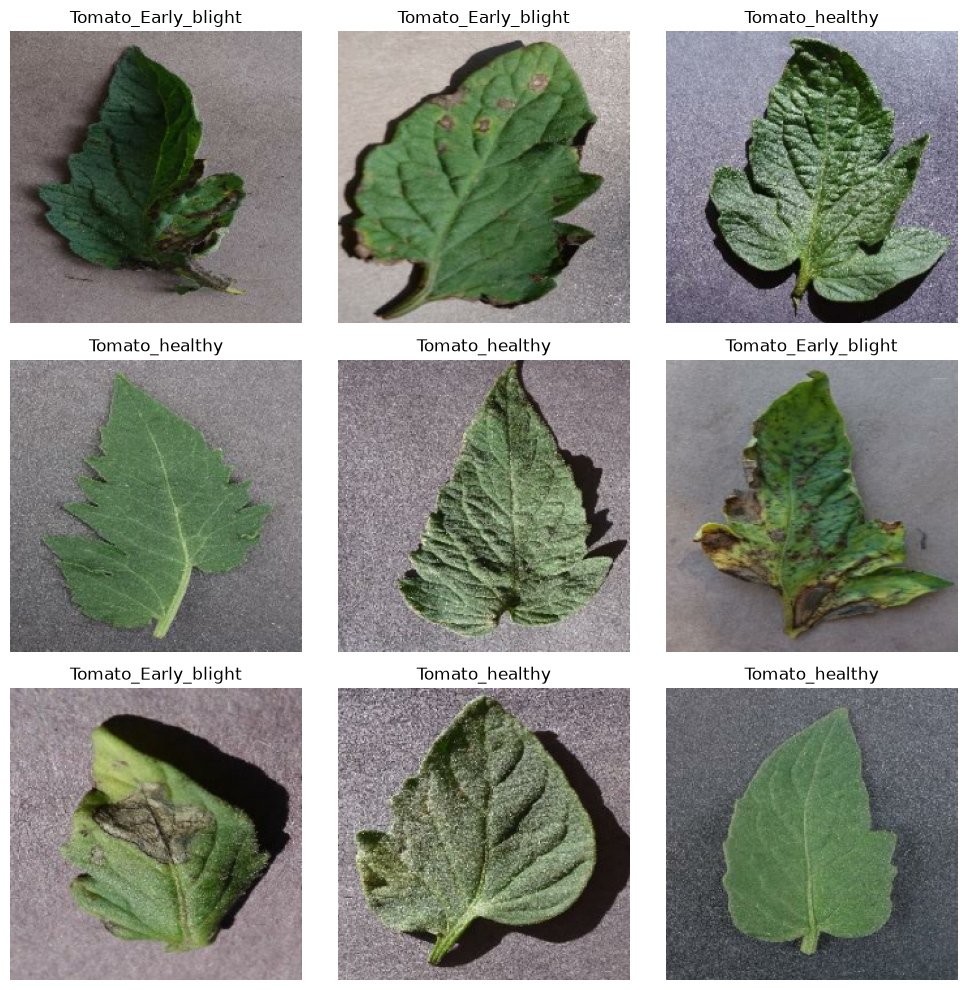

In [9]:

# STEP 9: Display Sample Images


plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

#### STEP 10: Normalize the Images

In [10]:

# STEP 10: Normalize Image Pixel Values


normalization_layer = tf.keras.layers.Rescaling(1./255)

##### Verify the normalization

In [11]:
# Take one batch from the training dataset
image_batch, label_batch = next(iter(train_dataset))

first_image = image_batch[0]

print("Pixel value before normalization")
print("Minimum:", np.min(first_image))
print("Maximum:", np.max(first_image))

normalized_image = normalization_layer(first_image)

print("\nPixel value after normalization")
print("Minimum:", np.min(normalized_image))
print("Maximum:", np.max(normalized_image))

Pixel value before normalization
Minimum: 0.0
Maximum: 252.75465

Pixel value after normalization
Minimum: 0.0
Maximum: 0.9911948


#### STEP 11: Data Augmentation

In [12]:

# STEP 11: Data Augmentation


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


##### Visualize Augmented Images

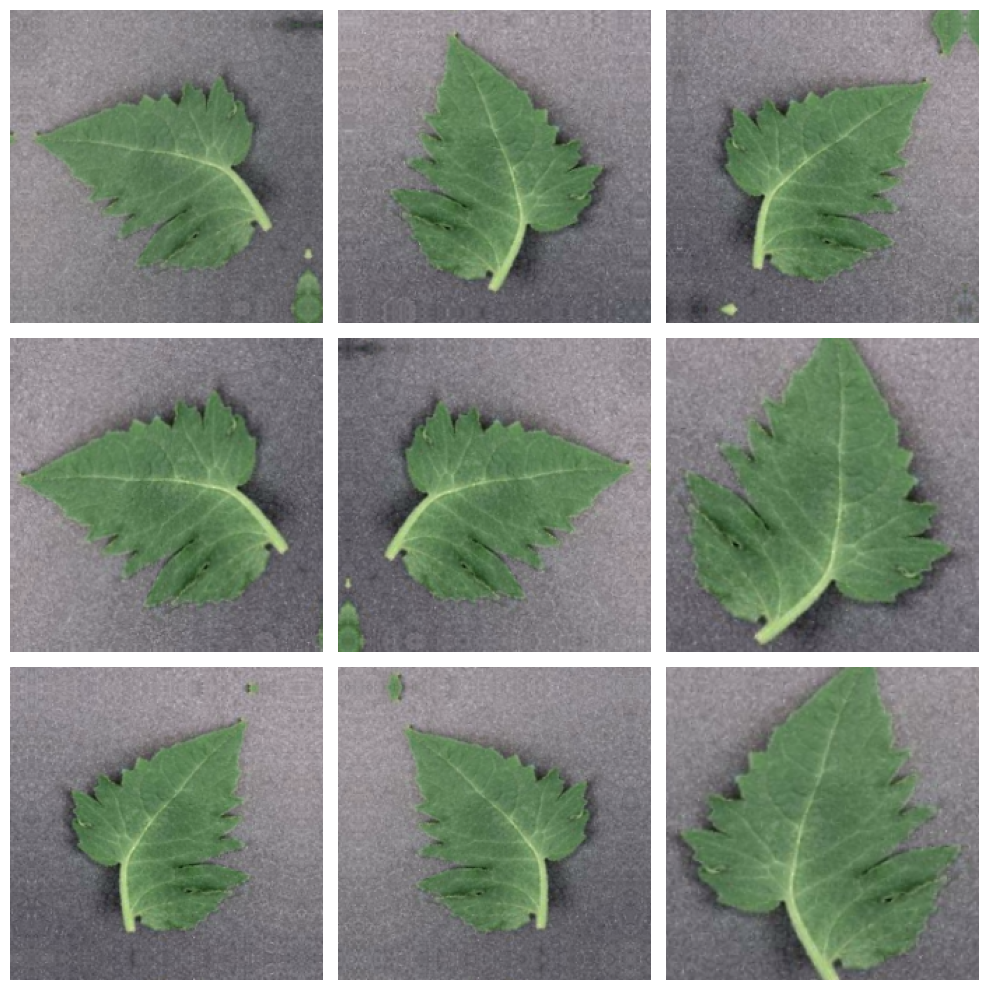

In [13]:

# Visualize Augmented Images


plt.figure(figsize=(10,10))

for images, _ in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        augmented = data_augmentation(tf.expand_dims(first_image, 0))

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented[0].numpy().astype("uint8"))

        plt.axis("off")

plt.tight_layout()
plt.show()

#### STEP 12: Optimize the Dataset Pipeline

In [14]:

# STEP 12: Optimize the Dataset Pipeline


AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset optimization completed.")

Dataset optimization completed.


#### STEP 13: Display Dataset Information

In [15]:

# STEP 13: Dataset Summary


print("Class Names:", class_names)

print("Number of Classes:", len(class_names))

print("Training Dataset:", train_dataset)

print("Validation Dataset:", validation_dataset)

print("Testing Dataset:", test_dataset)

Class Names: ['Tomato_Early_blight', 'Tomato_healthy']
Number of Classes: 2
Training Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Validation Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Testing Dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


#### STEP 14: Save the Preprocessing Configuration

In [16]:

# STEP 14: Save Configuration


IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "classes": class_names
}

print(config)

{'image_size': (224, 224), 'batch_size': 32, 'seed': 42, 'classes': ['Tomato_Early_blight', 'Tomato_healthy']}
